In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),])   # as mnist is 28*28 and lenet paper is 32* 32


In [5]:
# load the dataset
train_data = datasets.MNIST(root='./data',train=True,download=True,transform=transform)

test_data = datasets.MNIST(root='./data',train=False,download=True,transform=transform)


In [6]:
# mini batch training

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [7]:
# LeNet architecture

class LeNet5(nn.Module):

    def __init__(self):
        super(LeNet5, self).__init__()

        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)

        self.fc2 = nn.Linear(120, 84)

        self.fc3 = nn.Linear(84, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))

        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 16 * 5 * 5)

        x = self.relu(self.fc1(x))

        x = self.relu(self.fc2(x))

        x = self.fc3(x)

        return x

In [8]:
model = LeNet5().to(device)

In [9]:
criterion = nn.CrossEntropyLoss()

In [10]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
# learning rate scheduler 

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

In [12]:
# training loop

num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(device)

        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Predictions
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        # Progress bar
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")

        loop.set_postfix(loss=loss.item())

    # Scheduler step
    scheduler.step()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_accuracy)

    print(f"\nEpoch {epoch+1}")

    print(f"Loss     : {epoch_loss:.4f}")

    print(f"Accuracy : {epoch_accuracy:.2f}%")

Epoch [1/10]: 100%|██████████| 938/938 [00:24<00:00, 38.30it/s, loss=0.248]  



Epoch 1
Loss     : 0.2844
Accuracy : 91.08%


Epoch [2/10]: 100%|██████████| 938/938 [00:23<00:00, 39.41it/s, loss=0.00527]



Epoch 2
Loss     : 0.0801
Accuracy : 97.49%


Epoch [3/10]: 100%|██████████| 938/938 [00:21<00:00, 44.32it/s, loss=0.000577]


...


Epoch 8
Loss     : 0.0154
Accuracy : 99.48%


Epoch [9/10]: 100%|██████████| 938/938 [00:20<00:00, 45.08it/s, loss=0.000108]



Epoch 9
Loss     : 0.0138
Accuracy : 99.58%


Epoch [10/10]: 100%|██████████| 938/938 [00:20<00:00, 45.55it/s, loss=0.0117]  


Epoch 10
Loss     : 0.0117
Accuracy : 99.64%


In [13]:
# evaluate model 

model.eval()

correct = 0

total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 99.10%


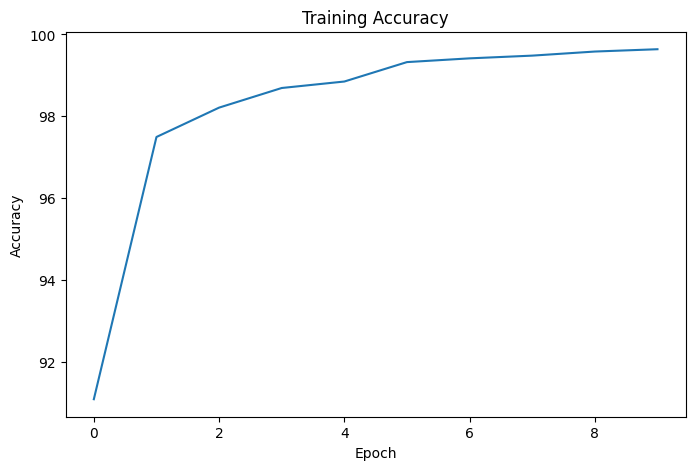

In [14]:
# plot accuracy curve

plt.figure(figsize=(8,5))

plt.plot(train_accuracies)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

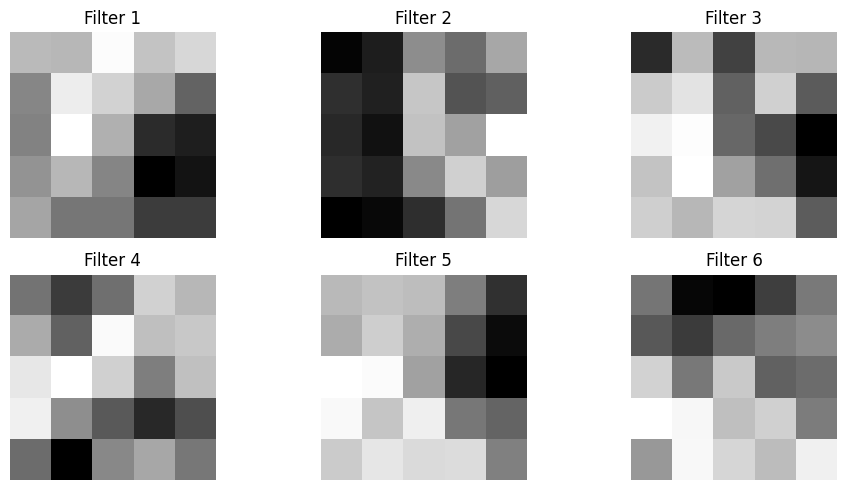

In [15]:
# visualize learned filters

filters = model.conv1.weight.data.cpu()

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(filters[i][0], cmap='gray')

    plt.axis('off')

    plt.title(f"Filter {i+1}")

plt.tight_layout()

plt.show()

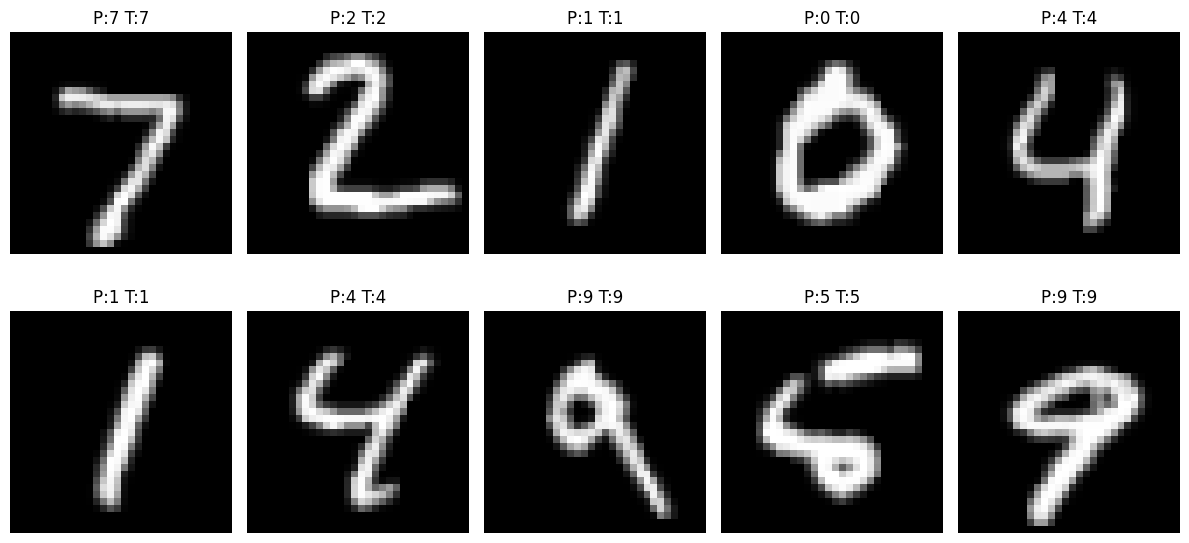

In [16]:
# visualize predictions

images, labels = next(iter(test_loader))

images = images.to(device)

outputs = model(images)

_, predicted = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i][0], cmap='gray')

    plt.title(f"P:{predicted[i].item()} T:{labels[i].item()}")

    plt.axis('off')

plt.tight_layout()

plt.show()